In [1]:
import joblib
import numpy as np
import pandas as pd

X_train_scaled = joblib.load("../models/X_train_scaled.pkl")
X_test_scaled  = joblib.load("../models/X_test_scaled.pkl")
y_train        = joblib.load("../models/y_train.pkl")
y_test         = joblib.load("../models/y_test.pkl")
feature_names  = joblib.load("../models/feature_names.pkl")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)
print("Feature names:", feature_names)

X_train_scaled shape: (8000, 7)
X_test_scaled shape:  (2000, 7)
Feature names: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


In [2]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained.")

Random Forest trained.


In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Predict
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)

# Evaluate at default threshold 0.5
print("=== Random Forest @ threshold 0.5 ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.4f}")

print("\nConfusion matrix:")
cm_rf = confusion_matrix(y_test, rf_pred)
print(pd.DataFrame(cm_rf,
    index=["Actual: Healthy", "Actual: Failure"],
    columns=["Pred: Healthy", "Pred: Failure"]))

=== Random Forest @ threshold 0.5 ===
Accuracy:  0.9760
Precision: 0.6562
Recall:    0.6176
F1 Score:  0.6364

Confusion matrix:
                 Pred: Healthy  Pred: Failure
Actual: Healthy           1910             22
Actual: Failure             26             42


In [4]:
# Get failure probabilities (column 1)
rf_failure_probs = rf_pred_proba[:, 1]

# Try multiple thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_at_t = (rf_failure_probs >= threshold).astype(int)
    p = precision_score(y_test, pred_at_t)
    r = recall_score(y_test, pred_at_t)
    f = f1_score(y_test, pred_at_t)
    cm = confusion_matrix(y_test, pred_at_t)
    print(f"Threshold {threshold}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}  "
          f"(caught {cm[1,1]}/{cm[1,0]+cm[1,1]} failures, {cm[0,1]} false alarms)")

Threshold 0.3: Precision=0.450  Recall=0.794  F1=0.574  (caught 54/68 failures, 66 false alarms)
Threshold 0.4: Precision=0.562  Recall=0.735  F1=0.637  (caught 50/68 failures, 39 false alarms)
Threshold 0.5: Precision=0.656  Recall=0.618  F1=0.636  (caught 42/68 failures, 22 false alarms)
Threshold 0.6: Precision=0.733  Recall=0.485  F1=0.584  (caught 33/68 failures, 12 false alarms)
Threshold 0.7: Precision=0.893  Recall=0.368  F1=0.521  (caught 25/68 failures, 3 false alarms)


Pick: Random Forest @ threshold 0.4
That's our winner. Final stats:

Catches 50 of 68 failures (73.5% recall)
56.2% precision (when it shouts "failure", it's right more than half the time)
F1 = 63.7%

This is dramatically better than yesterday's Logistic Regression (which caught 32 failures with F1 of 46.4%).

                   Feature  Importance
3              Torque [Nm]    0.314570
2   Rotational speed [rpm]    0.299808
4          Tool wear [min]    0.208979
0      Air temperature [K]    0.096950
1  Process temperature [K]    0.063599
5                   Type_L    0.009067
6                   Type_M    0.007026


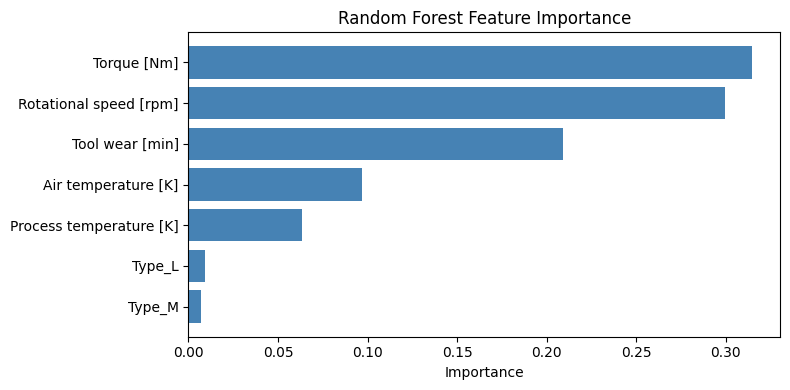

In [5]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

# Plot it
plt.figure(figsize=(8, 4))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.gca().invert_yaxis()  # most important on top
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [6]:
import joblib

# Save the Random Forest model and chosen threshold
joblib.dump(rf_model,  "../models/random_forest_model.pkl")
joblib.dump(0.4,       "../models/rf_threshold.pkl")

# Mark the winner — this tells the Streamlit app which model to use
joblib.dump("random_forest", "../models/winning_model_name.pkl")

print("Random Forest model and threshold saved.")
print("Marked 'random_forest' as the winning model.")

# Verify
import os
print("\nFiles in ../models/:")
for f in sorted(os.listdir("../models")):
    print(" ", f)

Random Forest model and threshold saved.
Marked 'random_forest' as the winning model.

Files in ../models/:
  X_test_scaled.pkl
  X_train_scaled.pkl
  feature_names.pkl
  logistic_regression_model.pkl
  lr_threshold.pkl
  random_forest_model.pkl
  rf_threshold.pkl
  scaler.pkl
  winning_model_name.pkl
  y_test.pkl
  y_train.pkl


# Day 7 — Random Forest Classifier

## What I did

### 1. Trained a Random Forest classifier
```python
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
```
Random Forest is an **ensemble** of decision trees. Each tree is trained on a random subset of rows AND considers a random subset of features at each split. Predictions are made by majority vote across all trees. The randomness reduces overfitting and produces more stable predictions than any single tree.

### 2. Compared LR vs RF at default threshold (0.5)

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Precision | 63.6% | 65.6% |
| Recall | 10.3% | **61.8%** |
| F1 | 17.7% | **63.6%** |

**Random Forest dramatically outperformed Logistic Regression on recall** without sacrificing precision. The `class_weight="balanced"` parameter handled imbalance automatically — no aggressive threshold tuning required.

### 3. Tuned the decision threshold

| Threshold | Precision | Recall | F1 | Caught | False alarms |
|---|---|---|---|---|---|
| 0.3 | 45.0% | 79.4% | 57.4% | 54 | 66 |
| **0.4** | **56.2%** | **73.5%** | **63.7%** | **50** | **39** |
| 0.5 | 65.6% | 61.8% | 63.6% | 42 | 22 |
| 0.6 | 73.3% | 48.5% | 58.4% | 33 | 12 |
| 0.7 | 89.3% | 36.8% | 52.1% | 25 | 3 |

Chose **threshold = 0.4** — highest F1 AND catches 8 more failures than threshold 0.5 with only 17 additional false alarms. For predictive maintenance, missed failures are far costlier than false alarms.

### 4. Examined feature importance

| Rank | Feature | Importance |
|---|---|---|
| 1 | Torque | 31.5% |
| 2 | Rotational speed | 30.0% |
| 3 | Tool wear | 20.9% |
| 4 | Air temperature | 9.7% |
| 5 | Process temperature | 6.4% |
| 6 | Type_L | 0.9% |
| 7 | Type_M | 0.7% |

The top three features (torque, speed, tool wear) account for **82% of predictive power**. Tool wear was particularly important here but got under-weighted by Logistic Regression — likely because failures kick in only after wear crosses a threshold (a non-linear pattern that linear models can't capture but trees can).

### 5. Saved the winning model
- `random_forest_model.pkl` — the trained model
- `rf_threshold.pkl` — chosen threshold (0.4)
- `winning_model_name.pkl` — flag pointing to RF as the production model

## Final model performance (Random Forest @ threshold 0.4)
- **Recall: 73.5%** — catches 3 out of 4 real failures
- **Precision: 56.2%** — when it shouts "failure," it's right more than half the time
- **F1: 63.7%** — strong balance for an imbalanced classification problem

## Key concepts learned today

| Concept | One-line summary |
|---|---|
| Decision Tree | Series of yes/no splits learned from data; tends to overfit alone. |
| Ensemble | Combining many models so their errors cancel out. |
| Random Forest | Ensemble of trees with random row + feature sampling. |
| `class_weight="balanced"` | Auto-weights minority class to handle imbalance. |
| Feature importance | Tree-based measure of how much each feature contributes to splits. |
| Linear vs non-linear models | Linear models miss threshold effects; trees capture them. |

## Next step: Day 8
Build a **Streamlit dashboard** (`app.py`) that:
- Loads the saved scaler, model, and threshold
- Takes user input via sliders/dropdowns
- Predicts failure probability live
- Shows feature importance and the prediction reasoning